In the previous part of the tutorial we looked at the effect of distributed renewable generation on the distribution grid, and how storage and peak shaving reduces this effect. In this tutorial we focus on evaluating the positive influence of energy hubs.

An energy hub is a smartly-controlled decentralized energy system within a defined area coordinating their generation, storage, conversion, and consumption to balance the local demand and collaborating towards a common goal.

One of the main advantages of an energy hub is the flexibility of generation and demand. Generation can be tailored to the more specific local needs, and demand can be handled by peak shifting (cooperation) and appropriate storage strategy.

First of all lets install the necessary packages for the visualizations in this tutorial by running the next cell:

In [ ]:
%pip install -q ipywidgets
%pip install ipympl
%pip install matplotlib 
%matplotlib widget

In [6]:
from illuminator.engine import Simulation
import functions_T3
import pandas as pd
import nest_asyncio
nest_asyncio.apply()

What can we use to evaluate the hubs?
In this step we chose our KPIs; CO2 emissions as a measure for sustainability, cost as a measure of efficiency and grid congestion as a measure for distribution efficiency.

Let's re-run the tutorial 3 simulation in it's worst case scenario, no renewables nor measures for grid congestion, this time we have 100 houses 

In [10]:
%%capture
CONFIG_FILE = 'data\Tutorial_physical_congestion_RES_bat.yaml'
simulation_RES_Bat = Simulation(CONFIG_FILE)

new_settings = {'Wind1': {'p_rated': 0},
                # 'Load1': {'houses': 100},
                'PV1': {'cap': 0},
                # 'Battery1': {'max_p': 40, 'min_p': -40, 'soc_min': 10, 'soc_max': 90},
                'Controller1': {'battery_active': False},
                # 'Grid1':{'connection_capacity' : 150, 'tolerance_limit': 0.67, 'critical_limit': 0.9},
                }

simulation_RES_Bat.edit_models(new_settings)

# you can switch between the selected days 2012-02-01 and 2012-07-06 by changing the date in the two lines below for better readibility it is advised to keep the observed time slot at 1 day
simulation_RES_Bat.set_scenario_param('start_time', '2012-02-01 00:00:00')
simulation_RES_Bat.set_scenario_param('end_time', '2012-02-01 23:45:00')

# run the simulation
simulation_RES_Bat.run()

2026-01-16 10:49:26.577 | INFO     | mosaik.async_scenario:start:508 - Starting 'Collector-0' (based on starter 'Collector')
2026-01-16 10:49:28.215 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSVload-0' (based on starter 'CSVload')
2026-01-16 10:49:28.359 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSVload-0 is using an outdated API version, namely 1. It should still work. You can suppress this warning by adding an explicit API version for this simulator in your SimConfig.
2026-01-16 10:49:28.359 | INFO     | mosaik.async_scenario:start:508 - Starting 'CSV_pv-0' (based on starter 'CSV_pv')
2026-01-16 10:49:28.502 | WARNING  | mosaik.async_scenario:user_warning:360 - c:\Users\dgeorgiadi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mosaik\adapters.py:120: UserWarning: Simulator CSV_pv-0 is using an outdated API version, namely 1

As we now don't generate with any renewables of our own we are tied to the CO2 production of the Netherlands' grid energy mix. We apply a (variable) CO2 calculation to the power demand, this will be the first KPI.  

We do a similar process to find the effect on cost of electricity, using the intraday market prices for the energy from the grid:

Total CO2 Emissions:        178.49 kg
                            0.18 tonnes
  Total Cost:               €67.52

✓ Results saved to: electricity_cost_results.csv

⚠ Grid congestion detected!
   Congestion events: 2


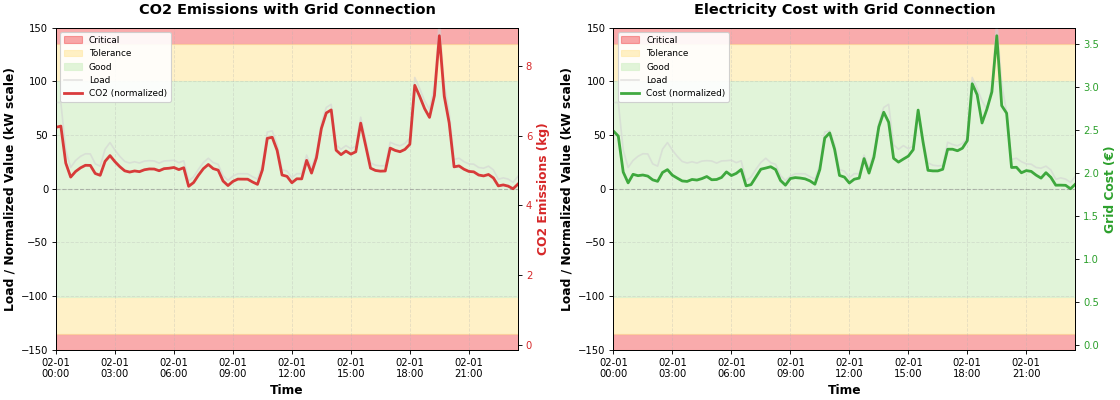

In [ ]:
from complete_co2_workflow import align_dates_and_calculate_co2

co2_results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    output_csv='co2_results.csv'
)

# Step 2: Calculate electricity costs
from electricity_cost_calculator import calculate_electricity_cost

cost_results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)



In [ ]:
from combined_analysis_plots import plot_combined_analysis

fig, (ax1, ax2) = plot_combined_analysis(
    co2_results_file='co2_results.csv',
    cost_results_file='electricity_cost_results.csv',
    consumption_file='out_Tutorial_RES_Bat.csv',
    connection_cap=150,
    critical_limit=0.9,
    tolerance_limit=0.67,
    figsize=(14, 5)  # You can adjust this if needed
)

In our 100 house energy hub we want to introduce our own renewable energy generation. Flexibility in generation and consumption to match supply to demand is a key advantage of energy hubs.

Run the code and select an amount of PV's, windturbines and storage to match the demand of the chosen hub. 

In [ ]:
from energy_dashboard_function import run_energy_dashboard
dashboard = run_energy_dashboard()


Run the simulation and wait for it to finish:

In [ ]:
from Slider_set_simulation import run_res_simulation
sim, settings, df = run_res_simulation(dashboard)  

Outputs plot:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_simulation_results(
    filepath="out_Tutorial_Renewables.csv",
    variables=None,
    title="Simulation Results",
    figsize=(10,5)
):
    """
    Plot selected variables from Illuminator output CSV.
    
    Parameters
    ----------
    filepath : str
        Path to the output CSV defined in YAML (monitor.file).
    variables : list of str
        List of columns to plot. If None, will show all available numeric columns.
    title : str
        Title of the plot.
    figsize : tuple
        Figure size.
    """

    # Load the data
    df = pd.read_csv(filepath)

    # Detect time column
    time_col = df.columns[0]
    df[time_col] = pd.to_datetime(df[time_col])

    # Autodetect variables if none specified
    if variables is None:
        variables = [c for c in df.columns if c != time_col]

    # Plot
    plt.figure(figsize=figsize)

    for var in variables:
        if var not in df.columns:
            print(f"⚠ Skipping '{var}' (not in dataset)")
            continue
        plt.plot(df[time_col], df[var], label=var)

    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_simulation_results()



Plot the CO2 emissions, the cost of electricity, and a check on grid congestion

In [ ]:
from electricity_cost_calculator_with_mix_plot import calculate_electricity_cost, plot_electricity_cost

results = calculate_electricity_cost(
    price_file='data\GUI_ENERGY_PRICES_202511272300-202511282300.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    output_csv='electricity_cost_results.csv'
)

plot_electricity_cost(results)
figsize=(10, 5)


from complete_co2_workflow import align_dates_and_calculate_co2, plot_co2_emissions

results = align_dates_and_calculate_co2(
    generation_file='data\GENERATION_PER_TYPE_20251125-20251202.csv',
    consumption_file='out_Tutorial_Renewables.csv',
    consumption_column='Controller1.dump',
    consumption_date_column='date'
)

plot_co2_emissions(results)
figsize=(10, 5)


In [ ]:
from renewable_electricity_cost_calculator2_improved4 import (
    calculate_renewable_and_grid_costs,
    plot_renewable_mix_costs,
    plot_cumulative_costs
)

In [ ]:
# Your slider values
n_pv_panels = dashboard["pv_size_slider"].value      # Number of PV panels
n_wind_turbines = dashboard["n_t_slider"].value       # Number of wind turbines  
battery_capacity = dashboard["storage_slider"].value  # Battery capacity in kWh

# Your file paths
PRICE_FILE = 'data\GUI_ENERGY_PRICES_202511272300-202511282300.csv'
OUTPUT_FILE = 'out_Tutorial_Renewables.csv'

In [ ]:
results = calculate_renewable_and_grid_costs(
    # Files
    price_file=PRICE_FILE,
    consumption_file=OUTPUT_FILE,
    renewable_output_file=OUTPUT_FILE,
    
    # Column names (adjust if different)
    consumption_column='Controller1.dump',
    pv_column='PV1.pv_gen',
    wind_column='Wind1.wind_gen',
    consumption_date_column='date',
    price_date_column='MTU (CET/CEST)',
    price_column='Day-ahead Price (EUR/MWh)',
    
    # System configuration (from sliders)
    n_pv=n_pv_panels,
    n_wind=n_wind_turbines,
    battery_capacity_kWh=battery_capacity,
    
    # LCOE parameters (defaults shown - adjust as needed)
    pv_cost_per_panel_EUR=800,
    pv_capacity_per_panel_kW=0.4,
    pv_lifetime_years=25,
    wind_cost_per_turbine_EUR=50000,
    wind_capacity_per_turbine_kW=10,
    wind_lifetime_years=20,
    battery_cost_per_kWh_EUR=600,
    battery_lifetime_years=10,
    discount_rate=0.05,
    
    # Output
    output_csv='./renewable_grid_cost_results.csv'
)


In [ ]:
# Plot 1: Renewable mix with stacked costs (different colors for each source)
plot_renewable_mix_costs(results)


Energy mix time dependent: https://transparency.entsoe.eu/generation/actual/perType/generation?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222026-01-15%22%2C%222026-01-15%22%5D%2C%22tz%22%3A%22CET%22%7D

Intraday day-ahead prices: https://transparency.entsoe.eu/market/energyPrices?appState=%7B%22sa%22%3A%5B%22BZN%7C10YNL----------L%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%222026-01-15%22%2C%22tz%22%3A%22CET%22%7D

Readjust the amount of PV's, wind and storage and evaluate the effect of your choice. The simulation results are stored in the pages here, page one has the results for the initial case with no renewables 